In [137]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark
from pyspark.sql.window import Window

import os
import sys

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [138]:
spark = (
    pyspark
    .sql
    .SparkSession
    .builder
    .appName('sparksession')
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "16g")
    .config("spark.executor.cores", "4")
    .config("spark.network.timeout", "600s") \
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")  # Only show errors, suppress warnings and info

In [282]:
ticker = 'I:SPX'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="second", from_="2022-10-16", to="2024-10-24", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = spark.createDataFrame(pd.DataFrame(price_performance))



ticker_hist = ticker_hist.withColumn("ticker", pyspark.sql.functions.lit(ticker))

ticker_hist = ticker_hist.withColumn(
    "Date", 
    pyspark.sql.functions.to_date(pyspark.sql.functions.col("Datetime"))
)
ticker_hist = ticker_hist.withColumn(
    "Time", 
    pyspark.sql.functions.date_format(
        pyspark.sql.functions.col("Datetime"),
        "HH:mm:ss"
    )
)

ticker_hist = ticker_hist.withColumn(
    "logOpen", pyspark.sql.functions.log("Open")
)

ticker_hist = ticker_hist.withColumn(
    "logClose", pyspark.sql.functions.log("Close")
)

ticker_hist = ticker_hist.withColumn(
    "logReturns", pyspark.sql.functions.log("Close")
)

ticker_hist = ticker_hist.withColumn(
    "logReturns", pyspark.sql.functions.col("logClose") - pyspark.sql.functions.col("logOpen")
)

9230981it [03:36, 42729.90it/s]


PySparkValueError: [CANNOT_DETERMINE_TYPE] Some of types cannot be determined after inferring.

In [193]:
ticker_hist = pd.DataFrame(price_performance)

In [195]:
ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']


ab_params = {}

ab_params['a'] = {}
ab_params['b'] = {}


print('analyzing')

dates = ticker_hist['Date'].unique()

for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]
    logReturns = ticker_hist_date['logOpen'].diff().iloc[1:]
    #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
    a = np.median(logReturns)
    b = np.sum(
            np.abs(logReturns - a)
    ) / (len(ticker_hist_date) - 1)
    ab_params['a'][date] = a
    ab_params['b'][date] = b

NameError: name 'a_params' is not defined

In [208]:
ticker_hist_date['logOpen'].diff().iloc[1:]

9181168   -0.000199
9181169   -0.000003
9181170   -0.000273
9181171   -0.000034
9181172    0.000195
             ...   
9203435   -0.000119
9203436   -0.000098
9203437    0.000060
9203438    0.000128
9203439   -0.000050
Name: logOpen, Length: 22272, dtype: float64

In [204]:
ticker_hist_date

,Open,Close,high,low,volume,Datetime,transactions,Date,Time,logClose,logOpen,logReturns
9181167,5834.50,5834.50,5834.50,5834.50,None,2024-10-23 09:30:01,None,2024-10-23,09:30:01,8.671544,8.671544,0.0
9181168,5833.34,5833.34,5833.34,5833.34,None,2024-10-23 09:30:02,None,2024-10-23,09:30:02,8.671345,8.671345,0.0
9181169,5833.32,5833.32,5833.32,5833.32,None,2024-10-23 09:30:03,None,2024-10-23,09:30:03,8.671342,8.671342,0.0
9181170,5831.73,5831.73,5831.73,5831.73,None,2024-10-23 09:30:04,None,2024-10-23,09:30:04,8.671069,8.671069,0.0
9181171,5831.53,5831.53,5831.53,5831.53,None,2024-10-23 09:30:05,None,2024-10-23,09:30:05,8.671035,8.671035,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9203435,5797.07,5797.07,5797.07,5797.07,None,2024-10-23 15:59:56,None,2024-10-23,15:59:56,8.665108,8.665108,0.0
9203436,5796.50,5796.50,5796.50,5796.50,None,2024-10-23 15:59:57,None,2024-10-23,15:59:57,8.665010,8.665010,0.0
9203437,5796.85,5796.85,5796.85,5796.85,None,2024-10-23 15:59:58,None,2024-10-23,15:59:58,8.665070,8.665070,0.0
9203438,5797.59,5797.59,5797.59,5797.59,None,2024-10-23 15:59:59,None,2024-10-23,15:59:59,8.665198,8.665198,0.0


In [209]:
ab_params = {}

ab_params['a'] = {}
ab_params['b'] = {}


print('analyzing')

dates = ticker_hist['Date'].unique()

for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]
    logReturns = ticker_hist_date['logOpen'].diff().iloc[1:]
    #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
    a = np.median(logReturns)
    b = np.sum(
            np.abs(logReturns - a)
    ) / (len(ticker_hist_date) - 1)
    ab_params['a'][date] = a
    ab_params['b'][date] = b

analyzing


425it [02:12,  3.20it/s]


In [210]:
ab_params_df = pd.DataFrame(ab_params)

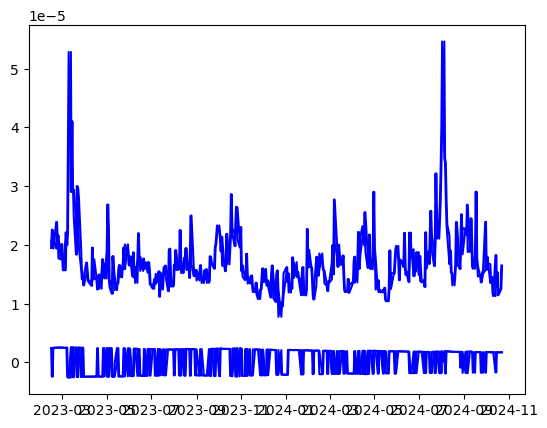

In [272]:
plt.plot(ab_params_df, 'b')

In [253]:
possible_final_returns = []
for r in tqdm(range(10000)):
    samples = np.random.laplace(loc=0, scale=lr_b.predict(ab_params_df[['a', 'b']])[-1], size=len(ticker_hist_date))

    possible_final_returns.append(samples.sum())

100%|███████████████████████████████████| 10000/10000 [00:07<00:00, 1376.27it/s]


In [247]:
lr_b.predict(ab_params_df[['a', 'b']])[-1]

np.float64(1.6712066943371763e-05)

In [246]:
lr_a.predict(ab_params_df[['a', 'b']])[-1]

np.float64(6.672163474007354e-07)

In [273]:
possible_final_prices = 5815. * np.exp(np.asarray(possible_final_returns))

In [280]:
payouts = []
for price in possible_final_prices:
    payout = (
        np.max([0., 5780. - price])
        - np.max([0., 5785. - price])
        - np.max([0., price - 5840.])
        + np.max([0., price - 5845.])
    )
    payouts.append(payout)

In [281]:
np.mean(np.asarray(payouts))

np.float64(-0.7297086194266316)

In [265]:
np.std(np.asarray(payouts))

np.float64(1.394619734068567)

(array([ 779.,   34.,   32.,   35.,   46.,   43.,   38.,   48.,   39.,
        8906.]),
 array([-5. , -4.5, -4. , -3.5, -3. , -2.5, -2. , -1.5, -1. , -0.5,  0. ]),
 <BarContainer object of 10 artists>)

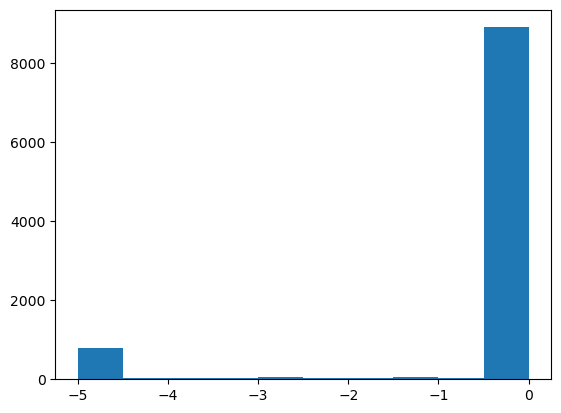

In [268]:
plt.hist(payouts)

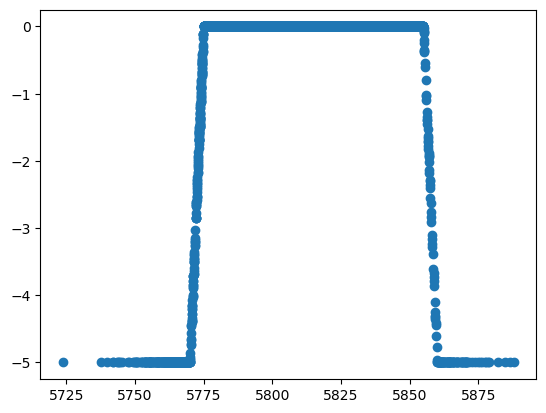

In [261]:
plt.scatter(possible_final_prices, payouts)

In [214]:
np.corrcoef(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

array([[1.       , 0.2124392],
       [0.2124392, 1.       ]])

In [215]:
np.corrcoef(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['b'].iloc[:-1])

array([[1.        , 0.70693268],
       [0.70693268, 1.        ]])

In [216]:
np.corrcoef(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['b'].iloc[:-1])

array([[1.        , 0.12110892],
       [0.12110892, 1.        ]])

In [217]:
np.corrcoef(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

array([[ 1.        , -0.02664778],
       [-0.02664778,  1.        ]])

In [218]:
ab_params_df['shifted_a'] = ab_params_df['a'].shift(-1)
ab_params_df['shifted_b'] = ab_params_df['b'].shift(-1)



In [224]:
lr_b = LinearRegression()

lr_b.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b'])
lr_b.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b'])


0.49975675108726203

In [221]:
lr_a = LinearRegression()

lr_a.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a'])
lr_a.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a'])


0.06196175319259167

In [ ]:
ticker_hist_pd = ticker_hist.toPandas()

In [ ]:
dates = ticker_hist_pd['Date'].unique()

In [ ]:
a_param = {}
b_param = {}

for date in tqdm(dates):
    a_param[date] = {}
    b_param[date] = {}
    
    ticker_hist_date = ticker_hist_pd[ticker_hist_pd['Date'] == date]
    ticker_hist_date_morn = ticker_hist_date[ticker_hist_date['Datetime'].dt.time <= datetime.time(12,45)]
    ticker_hist_date_eve = ticker_hist_date[ticker_hist_date['Datetime'].dt.time > datetime.time(12,45)]

    ticker_hist_date_morn = ticker_hist_date_morn.sort_values('logReturns').reset_index(drop = True)
    ticker_hist_date_eve = ticker_hist_date_eve.sort_values('logReturns').reset_index(drop = True)

    ticker_hist_date_morn['cumulative_volume'] = ticker_hist_date_morn['volume'].cumsum()/ticker_hist_date_morn['volume'].sum()
    ticker_hist_date_eve['cumulative_volume'] = ticker_hist_date_eve['volume'].cumsum()/ticker_hist_date_eve['volume'].sum()

    a_param_morn = ticker_hist_date_morn[ticker_hist_date_morn['cumulative_volume']>=0.5].iloc[0]['logReturns']
    a_param_eve = ticker_hist_date_eve[ticker_hist_date_eve['cumulative_volume']>=0.5].iloc[0]['logReturns']

    b_param_morn = np.sum(np.abs(ticker_hist_date_morn['logReturns'] - a_param_morn) * ticker_hist_date_morn['volume'])/ticker_hist_date_morn['volume'].sum()
    b_param_eve = np.sum(np.abs(ticker_hist_date_eve['logReturns'] - a_param_eve) * ticker_hist_date_eve['volume'])/ticker_hist_date_eve['volume'].sum()

    a_param[date]['morn'] = np.median(ticker_hist_date_morn['logReturns'])
    a_param[date]['eve'] = np.median(ticker_hist_date_eve['logReturns'])

    b_param[date]['morn'] = np.mean(np.abs(ticker_hist_date_morn['logReturns'] - a_param[date]['morn']))
    b_param[date]['eve'] = np.mean(np.abs(ticker_hist_date_eve['logReturns'] - a_param[date]['eve']))

    a_param[date]['all_day'] = np.median(ticker_hist_date['logReturns'])


    b_param[date]['all_day'] = np.mean(np.abs(ticker_hist_date['logReturns'] - a_param[date]['all_day']))

In [199]:
a_param_df = pd.DataFrame(a_params)
b_param_df = pd.DataFrame(b_params)

ValueError: If using all scalar values, you must pass an index

In [201]:
b_params

{datetime.date(2023, 2, 14): np.float64(0.0),
 datetime.date(2023, 2, 15): np.float64(2.2258791056450388e-10),
 datetime.date(2023, 2, 16): np.float64(0.0),
 datetime.date(2023, 2, 17): np.float64(0.0),
 datetime.date(2023, 2, 21): np.float64(0.0),
 datetime.date(2023, 2, 22): np.float64(0.0),
 datetime.date(2023, 2, 23): np.float64(0.0),
 datetime.date(2023, 2, 24): np.float64(5.856492635602133e-10),
 datetime.date(2023, 2, 27): np.float64(0.0),
 datetime.date(2023, 2, 28): np.float64(0.0),
 datetime.date(2023, 3, 1): np.float64(0.0),
 datetime.date(2023, 3, 2): np.float64(0.0),
 datetime.date(2023, 3, 3): np.float64(0.0),
 datetime.date(2023, 3, 6): np.float64(0.0),
 datetime.date(2023, 3, 7): np.float64(0.0),
 datetime.date(2023, 3, 8): np.float64(0.0),
 datetime.date(2023, 3, 9): np.float64(0.0),
 datetime.date(2023, 3, 10): np.float64(0.0),
 datetime.date(2023, 3, 13): np.float64(0.0),
 datetime.date(2023, 3, 14): np.float64(0.0),
 datetime.date(2023, 3, 15): np.float64(9.20579602

In [ ]:
np.corrcoef(b_param_df['morn'], b_param_df['eve'])

In [ ]:
np.corrcoef(
    b_param_df['all_day'].shift(-1).iloc[:-1], 
    b_param_df['all_day'].iloc[:-1]
)

In [ ]:
np.corrcoef(a_param_df['morn'], a_param_df['eve'])

In [154]:
from sklearn.linear_model import HuberRegressor

lr = LinearRegression()
lr.fit(
    b_param_df['all_day'].iloc[:-1].values.reshape(-1,1),
    b_param_df['all_day'].shift(-1).iloc[:-1]
)
lr.score(    
    b_param_df['all_day'].iloc[:-1].values.reshape(-1,1),
    b_param_df['all_day'].shift(-1).iloc[:-1]
)


0.5677754337737597

In [156]:
lr.coef_

array([0.75206276])

In [157]:
lr.intercept_

np.float64(5.9557276744979756e-06)

In [161]:
lr.predict(b_param_df['all_day'].values.reshape(-1,1))[-1]

np.float64(1.920872070665051e-05)

(0.0, 0.0001)

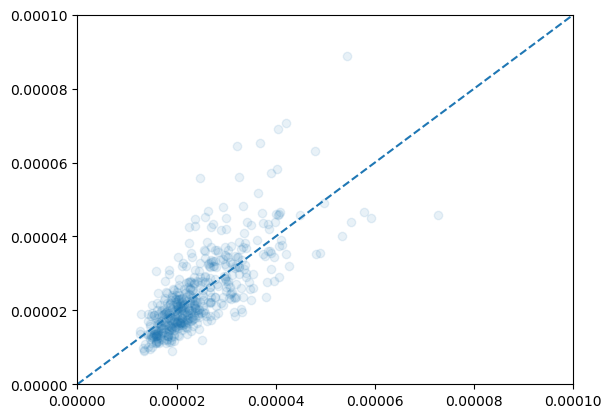

In [155]:
#plt.scatter(b_param_df['morn'], b_param_df['eve'], alpha=0.1)
plt.scatter(lr.predict(b_param_df['all_day'].iloc[:-1].values.reshape(-1,1)), b_param_df['all_day'].shift(-1).iloc[:-1], alpha=0.1)
plt.plot([0,1], [0,1], '--')
plt.xlim([0.0,0.0001])
plt.ylim([0.0,0.0001])


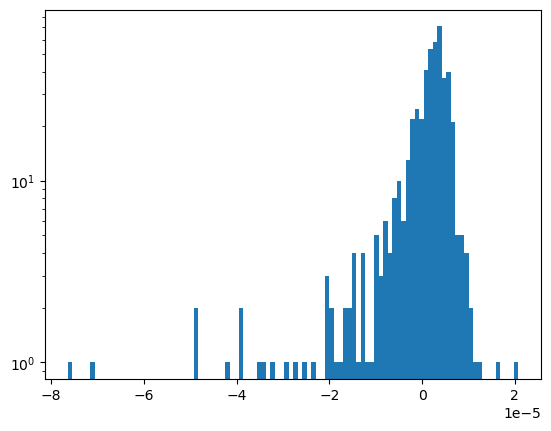

In [105]:
plt.hist(lr.predict(b_param_df['morn'].values.reshape(-1,1)) - b_param_df['eve'], bins = 100)
plt.yscale('log')

In [85]:
lr.coef_

array([8.64074271e-08])

In [76]:
lr.intercept_

np.float64(7.069303614368426e-06)

In [53]:
ticker_hist_date_eve[ticker_hist_date_eve['cumulative_volume']>=0.5].iloc[0]['logReturns']

np.float64(0.0)

In [106]:
ticker_hist_date = ticker_hist_pd[ticker_hist_pd['Date'] == dates[0]]

In [109]:
ticker_hist_date_morn = ticker_hist_date[ticker_hist_date['Datetime'].dt.time <= datetime.time(12,45)]
ticker_hist_date_eve = ticker_hist_date[ticker_hist_date['Datetime'].dt.time > datetime.time(12,45)]


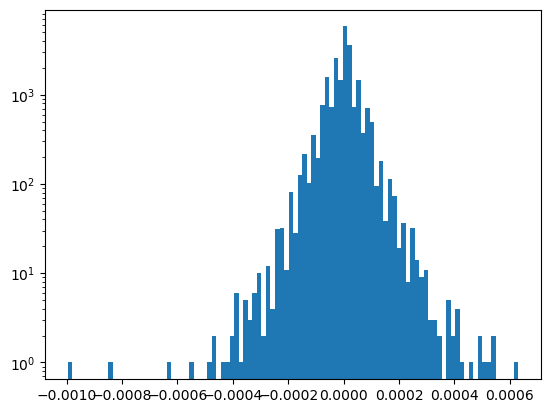

In [111]:
plt.hist(ticker_hist_date['logReturns'], bins=100)
plt.yscale('log')
plt.show()

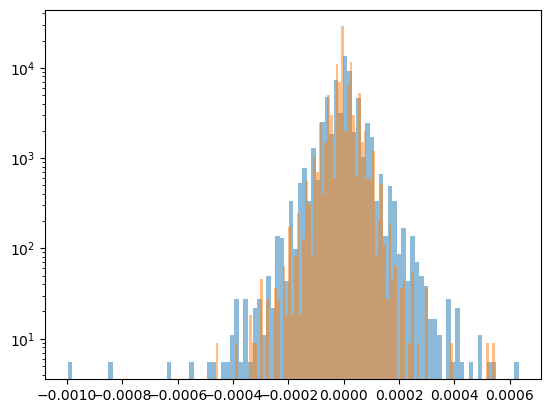

In [112]:
plt.hist(ticker_hist_date_morn['logReturns'], bins=100, alpha=0.5, density=True)
plt.hist(ticker_hist_date_eve['logReturns'], bins=100, alpha=0.5, density=True)

plt.yscale('log')
plt.show()

In [115]:
ticker_hist_date_morn

,Open,Close,high,low,volume,Datetime,transactions,ticker,Date,Time,logOpen,logClose,logReturns
0,364.0100,364.000,364.0300,363.970,373490.0,2022-10-17 09:30:00,469,SPY,2022-10-17,09:30:00,5.897181,5.897154,-0.000027
1,364.0000,364.020,364.1100,363.990,38700.0,2022-10-17 09:30:01,559,SPY,2022-10-17,09:30:01,5.897154,5.897209,0.000055
2,364.0200,364.140,364.1600,364.020,53912.0,2022-10-17 09:30:02,577,SPY,2022-10-17,09:30:02,5.897209,5.897538,0.000330
3,364.1400,364.370,364.3700,364.140,65433.0,2022-10-17 09:30:03,831,SPY,2022-10-17,09:30:03,5.897538,5.898170,0.000631
4,364.3600,364.470,364.4900,364.320,117555.0,2022-10-17 09:30:04,1228,SPY,2022-10-17,09:30:04,5.898142,5.898444,0.000302
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11277,366.3899,366.385,366.3899,366.385,470.0,2022-10-17 12:44:56,6,SPY,2022-10-17,12:44:56,5.903698,5.903685,-0.000013
11278,366.3850,366.385,366.3850,366.385,355.0,2022-10-17 12:44:57,6,SPY,2022-10-17,12:44:57,5.903685,5.903685,0.000000
11279,366.3900,366.395,366.4000,366.390,1503.0,2022-10-17 12:44:58,19,SPY,2022-10-17,12:44:58,5.903698,5.903712,0.000014
11280,366.3950,366.380,366.3950,366.380,2587.0,2022-10-17 12:44:59,16,SPY,2022-10-17,12:44:59,5.903712,5.903671,-0.000041


In [118]:
lr.predict(b_param_df.values.reshape(-1,1))[0]

np.float64(3.4578629977359775e-05)

In [162]:
samples = np.random.laplace(loc=0, scale=lr.predict(b_param_df['all_day'].values.reshape(-1,1))[-1], size=len(ticker_hist_date))


In [163]:
samples

array([-5.80863729e-05, -1.71358222e-05,  4.78957511e-05, ...,
        5.90871718e-06,  1.20324275e-04,  5.18658836e-05])

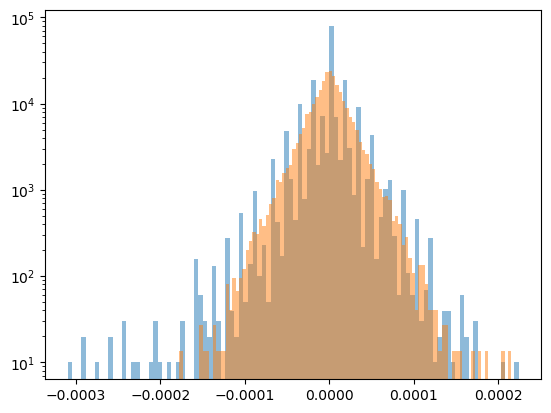

In [164]:
#plt.hist(ticker_hist_date_morn['logReturns'], bins=100, alpha=0.5, density=True)
plt.hist(ticker_hist_date['logReturns'], bins=100, alpha=0.5, density=True)
plt.hist(samples, bins = 100, alpha=0.5, density = True)
plt.yscale('log')
plt.show()

In [165]:
sum(ticker_hist_date_eve['logReturns'])

-0.002292332540465125

In [166]:
possible_final_returns = []
for r in tqdm(range(10000)):
    samples = np.random.laplace(loc=0, scale=lr.predict(b_param_df['all_day'].values.reshape(-1,1))[-1], size=len(ticker_hist_date))

    possible_final_returns.append(samples.sum())

100%|███████████████████████████████████| 10000/10000 [00:03<00:00, 2516.05it/s]


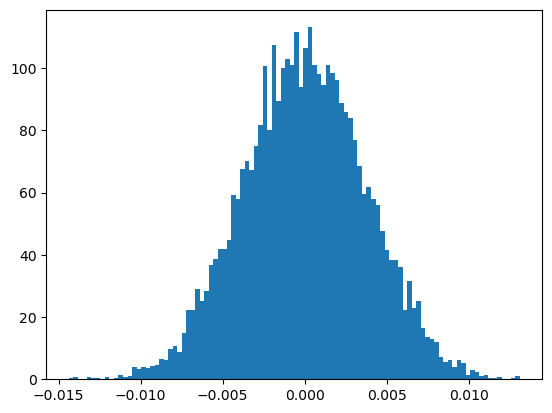

In [168]:
plt.hist(possible_final_returns, bins = 100, density = True)
plt.show()

In [170]:
possible_final_prices = 579.26 * np.exp(np.asarray(possible_final_returns))

In [171]:
possible_final_prices

array([580.38158953, 581.70811567, 583.37606322, ..., 578.5435061 ,
       579.61441378, 582.10720532])

In [177]:
np.max([0., 576. - price])


np.float64(0.0)

In [178]:
payouts = []
for price in possible_final_prices:
    payout = (
        np.max([0., 576. - price])
        - np.max([0., 577. - price])
        - np.max([0., price - 581.])
        + np.max([0., price - 582.])
    )
    payouts.append(payout)

In [ ]:
len(

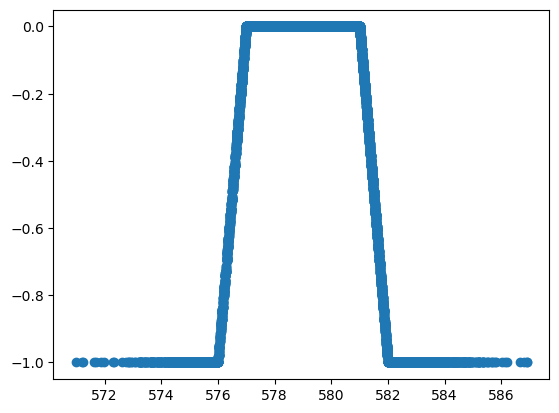

In [182]:
plt.scatter(possible_final_prices, payouts)

In [179]:
np.mean(np.asarray(payouts))

np.float64(-0.25819086244687234)

In [131]:
np.exp(np.asarray(possible_final_returns))

array([1.00246835, 1.0036509 , 1.00263132, ..., 0.99950375, 0.99574238,
       0.99980339])

In [33]:
ticker_hist_date['Time']

44717    09:30:00
44718    09:30:01
44719    09:30:02
44720    09:30:03
44721    09:30:04
           ...   
67015    15:59:56
67016    15:59:57
67017    15:59:58
67018    15:59:59
67019    16:00:00
Name: Time, Length: 22303, dtype: object

In [44]:
ticker_hist_date['Datetime'].dt.time<pd.to_datetime("12:00:00").time()

44717     True
44718     True
44719     True
44720     True
44721     True
         ...  
67015    False
67016    False
67017    False
67018    False
67019    False
Name: Datetime, Length: 22303, dtype: bool

In [ ]:
samples = np.random.laplace(loc=0, scale=1, size=1000)


In [46]:
ticker_hist_date[ticker_hist_date['Datetime'].dt.time < datetime.time(12, 45)]

,Open,Close,high,low,volume,Datetime,transactions,ticker,Date,Time,logOpen,logClose,logReturns
44717,368.99,368.8100,369.01,368.660,192520.0,2022-10-19 09:30:00,567,SPY,2022-10-19,09:30:00,5.910770,5.910282,-0.000488
44718,368.81,368.8100,368.84,368.300,15074.0,2022-10-19 09:30:01,229,SPY,2022-10-19,09:30:01,5.910282,5.910282,0.000000
44719,368.78,368.7200,368.98,368.720,12256.0,2022-10-19 09:30:02,232,SPY,2022-10-19,09:30:02,5.910200,5.910038,-0.000163
44720,368.74,368.7299,368.77,368.680,29663.0,2022-10-19 09:30:03,345,SPY,2022-10-19,09:30:03,5.910092,5.910064,-0.000027
44721,368.73,368.8700,368.93,368.730,11153.0,2022-10-19 09:30:04,184,SPY,2022-10-19,09:30:04,5.910065,5.910444,0.000380
...,...,...,...,...,...,...,...,...,...,...,...,...,...
55912,367.65,367.6700,367.67,367.650,639.0,2022-10-19 12:44:55,7,SPY,2022-10-19,12:44:55,5.907131,5.907186,0.000054
55913,367.67,367.6800,367.68,367.665,1096.0,2022-10-19 12:44:56,14,SPY,2022-10-19,12:44:56,5.907186,5.907213,0.000027
55914,367.68,367.6800,367.68,367.680,150.0,2022-10-19 12:44:57,6,SPY,2022-10-19,12:44:57,5.907213,5.907213,0.000000
55915,367.66,367.6800,367.68,367.660,2218.0,2022-10-19 12:44:58,16,SPY,2022-10-19,12:44:58,5.907159,5.907213,0.000054


In [4]:
dates = ticker_hist.select(pyspark.sql.functions.col('Date')).distinct().collect()

24/10/23 17:32:01 WARN TaskSetManager: Stage 0 contains a task of very large size (74269 KiB). The maximum recommended task size is 1000 KiB.


In [7]:

window_spec = Window.partitionBy('Date').orderBy('logReturns')
window_spec_total = Window.partitionBy('Date').rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

a_params = {}
b_params = {}

for date in tqdm(dates):
    ticker_hist_date = ticker_hist.filter(
        pyspark.sql.functions.col('Date') == date.Date
    )
    ticker_hist_date = ticker_hist_date.repartition(100, 'Date')

    ticker_hist_date = (
        ticker_hist_date
        .withColumn(
            'cumulative_volume',
            pyspark.sql.functions.sum('volume')
            .over(window_spec.orderBy('logReturns'))
        )
        .withColumn(
            'normalized_cumulative_volume',
            pyspark.sql.functions.col('cumulative_volume')
            /pyspark.sql.functions.sum('volume').over(
                window_spec_total
            )
        )
    )

    ticker_hist_date_row = ticker_hist_date.filter(
        pyspark.sql.functions.col('normalized_cumulative_volume')>=0.5
    ).orderBy('logReturns').first()
    
    a_param = ticker_hist_date_row['logReturns']

    b_param = (
        ticker_hist_date
        .withColumn(
            'abs_error',
            pyspark.sql.functions.abs(
                pyspark.sql.functions.lit(a_param) - pyspark.sql.functions.col('logReturns')
            ) 
            * pyspark.sql.functions.col('volume')
        )
        .agg(
            (
                pyspark.sql.functions.sum('abs_error') 
                /pyspark.sql.functions.sum('volume')
            )
            .alias('mae')
        )
    ).collect()[0]['mae']

    a_params[date.Date] = a_param
    b_params[date.Date] = b_param    

24/10/23 17:36:57 ERROR PythonRunner: Python worker exited unexpectedly (crashed)
java.net.SocketException: Connection reset
	at java.base/java.net.SocketInputStream.read(SocketInputStream.java:186)
	at java.base/java.net.SocketInputStream.read(SocketInputStream.java:140)
	at java.base/java.io.BufferedInputStream.fill(BufferedInputStream.java:252)
	at java.base/java.io.BufferedInputStream.read1(BufferedInputStream.java:292)
	at java.base/java.io.BufferedInputStream.read(BufferedInputStream.java:351)
	at java.base/java.io.DataInputStream.readFully(DataInputStream.java:200)
	at java.base/java.io.DataInputStream.readFully(DataInputStream.java:170)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:777)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:766)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.hasNext(PythonRunner.scala:525)
	at org.apache.spark.InterruptibleIterator.hasNext(InterruptibleIterator.scala:37)
	at 

Py4JJavaError: An error occurred while calling o273.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 3 in stage 22.0 failed 1 times, most recent failure: Lost task 3.0 in stage 22.0 (TID 454) (vedants-air.hsd1.pa.comcast.net executor driver): java.net.SocketException: Broken pipe (Write failed)
	at java.base/java.net.SocketOutputStream.socketWrite0(Native Method)
	at java.base/java.net.SocketOutputStream.socketWrite(SocketOutputStream.java:110)
	at java.base/java.net.SocketOutputStream.write(SocketOutputStream.java:150)
	at java.base/java.io.BufferedOutputStream.flushBuffer(BufferedOutputStream.java:81)
	at java.base/java.io.BufferedOutputStream.write(BufferedOutputStream.java:127)
	at java.base/java.io.DataOutputStream.write(DataOutputStream.java:107)
	at java.base/java.io.FilterOutputStream.write(FilterOutputStream.java:108)
	at org.apache.spark.api.python.PythonRDD$.write$1(PythonRDD.scala:310)
	at org.apache.spark.api.python.PythonRDD$.$ano

In [11]:
   (
        ticker_hist_date
        .withColumn(
            'abs_error',
            pyspark.sql.functions.abs(
                pyspark.sql.functions.lit(a_param) - pyspark.sql.functions.col('logReturns')
            ) 
            * pyspark.sql.functions.col('volume')
        )
        .agg(
            (
                pyspark.sql.functions.sum('abs_error') 
                /pyspark.sql.functions.sum('volume')
            )
            .alias('mae')
        )
    ).collect()[0]['mae']

24/10/23 17:18:17 WARN TaskSetManager: Stage 22 contains a task of very large size (74269 KiB). The maximum recommended task size is 1000 KiB.


4.600460117068257e-05

In [15]:
test = ticker_hist.filter(
    pyspark.sql.functions.col('Date') == pyspark.sql.functions.to_date(pyspark.sql.functions.lit("2024-10-10"))
).toPandas()

24/10/23 10:20:12 WARN TaskSetManager: Stage 4 contains a task of very large size (74269 KiB). The maximum recommended task size is 1000 KiB.


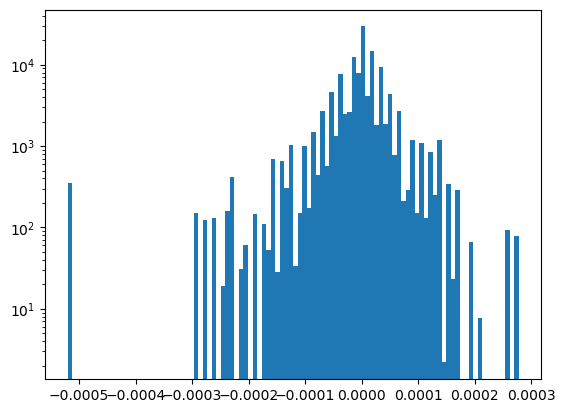

In [21]:
plt.hist(test['logReturns'], weights = test['volume'],  bins=100, density = True)
plt.yscale('log')

In [22]:
np.median(test['logReturns'])

np.float64(0.0)

In [26]:
dates = ticker_hist.select(pyspark.sql.functions.col('Date')).distinct().collect()

24/10/23 10:56:37 WARN TaskSetManager: Stage 8 contains a task of very large size (74269 KiB). The maximum recommended task size is 1000 KiB.


In [37]:
len(test)

17752

In [36]:
ticker_hist.filter(
    pyspark.sql.functions.col('Date') == dates[0].Date
).toPandas()

24/10/23 10:59:04 WARN TaskSetManager: Stage 11 contains a task of very large size (74269 KiB). The maximum recommended task size is 1000 KiB.


,Open,Close,high,low,volume,Datetime,transactions,ticker,Date,Time,logOpen,logClose,logReturns
0,396.05,396.040,396.100,396.00,172847.0,2022-11-29 09:30:00,311,SPY,2022-11-29,09:30:00,5.981540,5.981515,-0.000025
1,396.05,396.000,396.090,396.00,23781.0,2022-11-29 09:30:01,282,SPY,2022-11-29,09:30:01,5.981540,5.981414,-0.000126
2,395.99,395.940,395.990,395.94,11174.0,2022-11-29 09:30:02,271,SPY,2022-11-29,09:30:02,5.981389,5.981263,-0.000126
3,395.96,395.940,395.990,395.91,10862.0,2022-11-29 09:30:03,228,SPY,2022-11-29,09:30:03,5.981313,5.981263,-0.000051
4,395.95,395.880,395.950,395.87,9693.0,2022-11-29 09:30:04,398,SPY,2022-11-29,09:30:04,5.981288,5.981111,-0.000177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20756,395.29,395.320,395.345,395.29,10282.0,2022-11-29 15:59:56,80,SPY,2022-11-29,15:59:56,5.979620,5.979696,0.000076
20757,395.30,395.285,395.320,395.26,26927.0,2022-11-29 15:59:57,171,SPY,2022-11-29,15:59:57,5.979645,5.979607,-0.000038
20758,395.30,395.300,395.340,395.28,15409.0,2022-11-29 15:59:58,114,SPY,2022-11-29,15:59:58,5.979645,5.979645,0.000000
20759,395.32,395.250,395.340,395.25,35382.0,2022-11-29 15:59:59,157,SPY,2022-11-29,15:59:59,5.979696,5.979518,-0.000177


In [74]:
ticker_hist_date = ticker_hist.filter(
    pyspark.sql.functions.col('Date') == date.Date
).toPandas()

24/10/23 16:27:11 WARN TaskSetManager: Stage 67 contains a task of very large size (74269 KiB). The maximum recommended task size is 1000 KiB.


In [75]:
ticker_hist_date

,Open,Close,high,low,volume,Datetime,transactions,ticker,Date,Time,logOpen,logClose,logReturns
0,396.05,396.040,396.100,396.00,172847.0,2022-11-29 09:30:00,311,SPY,2022-11-29,09:30:00,5.981540,5.981515,-0.000025
1,396.05,396.000,396.090,396.00,23781.0,2022-11-29 09:30:01,282,SPY,2022-11-29,09:30:01,5.981540,5.981414,-0.000126
2,395.99,395.940,395.990,395.94,11174.0,2022-11-29 09:30:02,271,SPY,2022-11-29,09:30:02,5.981389,5.981263,-0.000126
3,395.96,395.940,395.990,395.91,10862.0,2022-11-29 09:30:03,228,SPY,2022-11-29,09:30:03,5.981313,5.981263,-0.000051
4,395.95,395.880,395.950,395.87,9693.0,2022-11-29 09:30:04,398,SPY,2022-11-29,09:30:04,5.981288,5.981111,-0.000177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20756,395.29,395.320,395.345,395.29,10282.0,2022-11-29 15:59:56,80,SPY,2022-11-29,15:59:56,5.979620,5.979696,0.000076
20757,395.30,395.285,395.320,395.26,26927.0,2022-11-29 15:59:57,171,SPY,2022-11-29,15:59:57,5.979645,5.979607,-0.000038
20758,395.30,395.300,395.340,395.28,15409.0,2022-11-29 15:59:58,114,SPY,2022-11-29,15:59:58,5.979645,5.979645,0.000000
20759,395.32,395.250,395.340,395.25,35382.0,2022-11-29 15:59:59,157,SPY,2022-11-29,15:59:59,5.979696,5.979518,-0.000177


In [76]:
from pyspark.sql.window import Window


a_params = {}
b_params = {}

for date in tqdm(dates):
    ticker_hist_date = ticker_hist.filter(
        pyspark.sql.functions.col('Date') == date.Date
    ).toPandas()

    ticker_hist_date = ticker_hist_date.sort_values('logReturns').reset_index(drop = True)

    ticker_hist_date['cumulative_volume'] = (
        ticker_hist_date['volume'].cumsum()
        /ticker_hist_date['volume'].sum()
    )

    a_param = ticker_hist_date[ticker_hist_date['cumulative_volume']>=0.5].iloc[0]['logReturns']
    b_param = (
        np.sum(
            abs(
                a_param - ticker_hist_date['logReturns']
            )
            *ticker_hist_date['volume']
        )
        /ticker_hist_date['volume'].sum()
    )

    a_params[date] = a_param
    b_params[date] = b_param

  0%|▏                                        | 2/501 [00:37<2:51:04, 20.57s/it]24/10/23 16:31:20 WARN TaskSetManager: Stage 70 contains a task of very large size (74269 KiB). The maximum recommended task size is 1000 KiB.
24/10/23 16:32:16 ERROR Executor: Exception in task 4.0 in stage 70.0 (TID 303)]
java.net.SocketException: Connection reset
	at java.base/java.net.SocketInputStream.read(SocketInputStream.java:186)
	at java.base/java.net.SocketInputStream.read(SocketInputStream.java:140)
	at java.base/java.io.BufferedInputStream.fill(BufferedInputStream.java:252)
	at java.base/java.io.BufferedInputStream.read1(BufferedInputStream.java:292)
	at java.base/java.io.BufferedInputStream.read(BufferedInputStream.java:351)
	at java.base/java.io.DataInputStream.readFully(DataInputStream.java:200)
	at java.base/java.io.DataInputStream.readFully(DataInputStream.java:170)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:777)
	at org.apache.spark.api.python.PythonRunne

Py4JJavaError: An error occurred while calling o572.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 4 in stage 70.0 failed 1 times, most recent failure: Lost task 4.0 in stage 70.0 (TID 303) (vedants-air.hsd1.pa.comcast.net executor driver): java.net.SocketException: Connection reset
	at java.base/java.net.SocketInputStream.read(SocketInputStream.java:186)
	at java.base/java.net.SocketInputStream.read(SocketInputStream.java:140)
	at java.base/java.io.BufferedInputStream.fill(BufferedInputStream.java:252)
	at java.base/java.io.BufferedInputStream.read1(BufferedInputStream.java:292)
	at java.base/java.io.BufferedInputStream.read(BufferedInputStream.java:351)
	at java.base/java.io.DataInputStream.readFully(DataInputStream.java:200)
	at java.base/java.io.DataInputStream.readFully(DataInputStream.java:170)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:777)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(Pyth

In [80]:
ticker_hist.filter(pyspark.sql.functions.col('Date') == date.Date).repartition(10).toPandas()

24/10/23 16:35:01 WARN TaskSetManager: Stage 74 contains a task of very large size (74269 KiB). The maximum recommended task size is 1000 KiB.
24/10/23 16:35:56 ERROR Executor: Exception in task 7.0 in stage 74.0 (TID 323)]
java.net.SocketException: Connection reset
	at java.base/java.net.SocketInputStream.read(SocketInputStream.java:186)
	at java.base/java.net.SocketInputStream.read(SocketInputStream.java:140)
	at java.base/java.io.BufferedInputStream.read1(BufferedInputStream.java:290)
	at java.base/java.io.BufferedInputStream.read(BufferedInputStream.java:351)
	at java.base/java.io.DataInputStream.readFully(DataInputStream.java:200)
	at java.base/java.io.DataInputStream.readFully(DataInputStream.java:170)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:777)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:766)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.hasNext(PythonRunner.scala:525)
	at org.apache.spark.I

Py4JJavaError: An error occurred while calling o590.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 7 in stage 74.0 failed 1 times, most recent failure: Lost task 7.0 in stage 74.0 (TID 323) (vedants-air.hsd1.pa.comcast.net executor driver): java.net.SocketException: Connection reset
	at java.base/java.net.SocketInputStream.read(SocketInputStream.java:186)
	at java.base/java.net.SocketInputStream.read(SocketInputStream.java:140)
	at java.base/java.io.BufferedInputStream.read1(BufferedInputStream.java:290)
	at java.base/java.io.BufferedInputStream.read(BufferedInputStream.java:351)
	at java.base/java.io.DataInputStream.readFully(DataInputStream.java:200)
	at java.base/java.io.DataInputStream.readFully(DataInputStream.java:170)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:777)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:766)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIt